In this notebook, we fine-tune the **DualEncoderFNO v8** model using **L2 loss** instead of H1.

**Motivation:**
- v8 was trained with H1 loss (values + gradients). The FEM ground truth contains discretization
  noise ("saw-tooth"), so H1 penalizes the model for producing physically smoother fields than the
  noisy GT. Switching to L2 removes that gradient penalty and focuses purely on point-wise accuracy.
- This is a refinement step, not a full retrain: we start from the v8 weights (already well-trained)
  and fine-tune with a very small learning rate so the learned representations are not disrupted.

**Changes vs v8:**
- Training loss: `WeightedVoigtLoss(LpLoss)` (L2) instead of `WeightedVoigtLoss(H1Loss)`
- Learning rate: 1e-5 (vs 1e-3 in v8)
- No LR scheduler — fixed small lr to avoid instability
- 50 epochs with early stopping (patience = 10)
- Model initialised from `rve2_fno_v8_params.pth`

### 1. Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from neuralop import LpLoss, H1Loss
from rve_analyzer import RVEDataset, DualEncoderFNO, Trainer, HomogenizedLoss, WeightedVoigtLoss

### 2. Configuration

In [2]:
from types import SimpleNamespace

cfg = SimpleNamespace(**{})

In [3]:
cfg.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {cfg.device}")

Device: cuda


In [4]:
cfg.h5_path     = Path("../master_data/rve_run2.h5")
cfg.batch_size  = 64
cfg.num_workers = 0
cfg.seed        = 42
torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)

### 3. Datasets & DataLoader

In [5]:
cfg.in_memory = True
cfg.fraction  = 1.00

train_dataset = RVEDataset(cfg.h5_path, split='train', in_memory=cfg.in_memory,
                           fraction=cfg.fraction, augment=True)
val_dataset   = RVEDataset(cfg.h5_path, split='val',   in_memory=cfg.in_memory,
                           fraction=cfg.fraction, augment=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

sample_xl, sample_xg, sample_y = train_dataset[0]
in_channels  = sample_xl.shape[0]
out_channels = sample_y.shape[0]
n_macro      = sample_xg.shape[0]

print(f"in_channels={in_channels}, out_channels={out_channels}, n_macro={n_macro}")

Loading 100% of 'train' split into RAM. This may take a moment...
Loading 100% of 'val' split into RAM. This may take a moment...
Train: 60000 | Val: 20000
in_channels=1, out_channels=3, n_macro=3


In [6]:
persistent_workers = True if cfg.num_workers > 0 else False
prefetch_factor    = 4    if cfg.num_workers > 0 else None

train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=cfg.num_workers, pin_memory=True,
                          persistent_workers=persistent_workers, prefetch_factor=prefetch_factor)

val_loader   = DataLoader(val_dataset,   batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=True,
                          persistent_workers=persistent_workers, prefetch_factor=prefetch_factor)

### 4. Load v9 model

In [7]:
# Re-instantiate the model from the saved v9 config
config = torch.load("../checkpoints/rve2_fno_v9_config.pth", weights_only=False)
model  = DualEncoderFNO(**config).to(cfg.device)

# Load v9 weights as starting point
checkpoint = torch.load("../checkpoints/rve2_fno_v9_params.pth", weights_only=True)
model.load_state_dict(checkpoint['model_state_dict'])

print(f"Loaded v9 checkpoint (epoch {checkpoint['epoch']}, val_loss={checkpoint['val_loss']:.6f})")
print(f"Parameters: {model.count_parameters():,}")

Loaded v9 checkpoint (epoch 49, val_loss=0.095321)
Parameters: 4,839,363


In [8]:
# Save v9 config (same architecture as v8)
model.save_config("../checkpoints/rve2_fno_v10_config.pth")

Saved configuration at ../checkpoints/rve2_fno_v10_config.pth


### 5. Fine-tuning with L2 loss

In [9]:
cfg.epochs    = 50
cfg.lr        = 1e-5       # Small lr: refine without disrupting previous representations
cfg.weight_decay = 1e-4
cfg.patience  = 10
cfg.max_grad_norm = 1.0

l2loss = WeightedVoigtLoss(LpLoss(d=2, p=2, reduction='mean'))
h1loss = WeightedVoigtLoss(H1Loss(d=2, reduction='mean'))
hgloss = WeightedVoigtLoss(HomogenizedLoss())

val_metrics = {
    'l2': l2loss,
    'h1': h1loss,
    'hg': hgloss,
}

In [10]:
trainer = Trainer(
    model         = model,
    loss_fun      = l2loss,          # L2
    val_metrics   = val_metrics,
    wandb_log     = False,
    device        = cfg.device,
    save_dir      = "../checkpoints",
    min_delta     = 1e-7,
    max_grad_norm = cfg.max_grad_norm,
    verbose       = True,
)

In [11]:
# Fixed small lr — no scheduler to avoid cutting lr before the fine-tuning has effect
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = cfg.lr,
    weight_decay = cfg.weight_decay,
)

history = trainer.fit(
    train_loader = train_loader,
    val_loader   = val_loader,
    epochs       = cfg.epochs,
    optimizer    = optimizer,
    scheduler    = None,
    patience     = cfg.patience,
    model_name   = "rve2_fno_v10_params.pth",
    verbose      = True,
)

DualEncoderFNO Training: 50 epochs



   Best model saved (Epoch 1)
Epoch   1/50 | Train Loss: 0.072877 | Val Loss: 0.095362 | Val L2: 0.095362 | H1: 0.128397 | HG: 0.023875 | LR: 1.00e-05


   Best model saved (Epoch 2)
Epoch   2/50 | Train Loss: 0.072825 | Val Loss: 0.095278 | Val L2: 0.095278 | H1: 0.128356 | HG: 0.023989 | LR: 1.00e-05


Epoch   3/50 | Train Loss: 0.072766 | Val Loss: 0.095352 | Val L2: 0.095352 | H1: 0.128458 | HG: 0.024446 | LR: 1.00e-05


   Best model saved (Epoch 4)
Epoch   4/50 | Train Loss: 0.072716 | Val Loss: 0.095129 | Val L2: 0.095129 | H1: 0.128395 | HG: 0.023651 | LR: 1.00e-05


...

   Best model saved (Epoch 46)
Epoch  46/50 | Train Loss: 0.071161 | Val Loss: 0.093870 | Val L2: 0.093870 | H1: 0.128248 | HG: 0.023265 | LR: 1.00e-05


Epoch  47/50 | Train Loss: 0.071127 | Val Loss: 0.093874 | Val L2: 0.093874 | H1: 0.128293 | HG: 0.023231 | LR: 1.00e-05


Epoch  48/50 | Train Loss: 0.071122 | Val Loss: 0.093882 | Val L2: 0.093882 | H1: 0.128375 | HG: 0.023509 | LR: 1.00e-05


   Best model saved (Epoch 49)
Epoch  49/50 | Train Loss: 0.071077 | Val Loss: 0.093737 | Val L2: 0.093737 | H1: 0.128232 | HG: 0.023316 | LR: 1.00e-05


Epoch  50/50 | Train Loss: 0.071080 | Val Loss: 0.093768 | Val L2: 0.093768 | H1: 0.128266 | HG: 0.023185 | LR: 1.00e-05

 Training finished. Best epoch: 49 (Loss = 0.093737)
Total training time: 06:07:21.51


### 6. Training curves

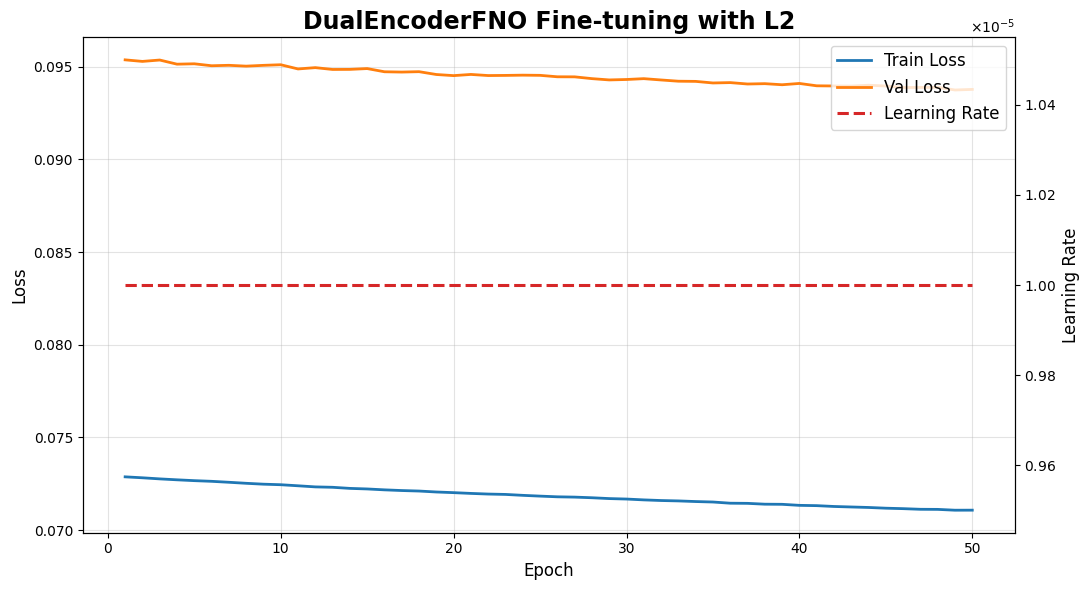

In [12]:
trainer.plot_history(title="DualEncoderFNO Fine-tuning with L2")

### 7. v8 vs v9 — loss comparison

In [13]:
# Compare final val metrics between v8 and v9
v8_val_loss = checkpoint['val_loss']   # H1 loss from v8 checkpoint
v9_val_loss = trainer.best_loss        # L2 loss from v9

print(f"v8 best val loss (H1, WeightedVoigt) : {v8_val_loss:.6f}")
print(f"v9 best val loss (L2, WeightedVoigt) : {v9_val_loss:.6f}")
print()
print("Val metrics at v9 best epoch:")
for name, values in history.items():
    if name.startswith('val_') and values:
        best_epoch = trainer.best_epoch - 1
        print(f"  {name}: {values[best_epoch]:.6f}")

v8 best val loss (H1, WeightedVoigt) : 0.095321
v9 best val loss (L2, WeightedVoigt) : 0.093737

Val metrics at v9 best epoch:
  val_loss: 0.093737
  val_l2: 0.093737
  val_h1: 0.128232
  val_hg: 0.023316
